# XGBoost 任务工时预测 - 逐步训练

本 Notebook 将训练过程拆分为多个步骤，每一步都可以单独运行和查看结果。

## 步骤 1: 导入库和设置环境

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子
np.random.seed(42)

print("✅ 环境准备完成")
print(f"XGBoost 版本: {xgb.__version__}")
print(f"Pandas 版本: {pd.__version__}")

✅ 环境准备完成
XGBoost 版本: 3.2.0
Pandas 版本: 2.2.3


## 步骤 2: 加载数据

In [14]:
# 加载训练数据
df = pd.read_csv('training_data.csv')

print(f"数据形状: {df.shape}")
print(f"\n列名: {df.columns.tolist()}")
print(f"\n数据类型:")
print(df.dtypes)
print(f"\n缺失值统计:")
print(df.isnull().sum())

# 显示前 10 行
df.head(10)

数据形状: (1000, 13)

列名: ['task_type', 'priority', 'story_points', 'title_length', 'description_length', 'labels_count', 'created_month', 'created_quarter', 'created_day_of_week', 'days_to_due', 'assignee_id', 'project_id', 'actual_hours']

数据类型:
task_type               object
priority                object
story_points             int64
title_length             int64
description_length       int64
labels_count             int64
created_month            int64
created_quarter          int64
created_day_of_week      int64
days_to_due              int64
assignee_id              int64
project_id               int64
actual_hours           float64
dtype: object

缺失值统计:
task_type              0
priority               0
story_points           0
title_length           0
description_length     0
labels_count           0
created_month          0
created_quarter        0
created_day_of_week    0
days_to_due            0
assignee_id            0
project_id             0
actual_hours           0
dtype:

,task_type,priority,story_points,title_length,description_length,labels_count,created_month,created_quarter,created_day_of_week,days_to_due,assignee_id,project_id,actual_hours
0,STORY,HIGH,2,66,138,2,5,2,3,83,8,5,15.5
1,EPIC,MEDIUM,2,81,105,1,11,4,5,87,6,2,15.1
2,TASK,LOW,8,16,143,3,1,1,6,13,3,4,44.1
3,BUG,MEDIUM,2,87,142,1,10,4,5,69,1,2,7.3
4,STORY,LOW,2,65,389,3,3,1,3,67,2,2,15.0
5,STORY,MEDIUM,5,76,0,2,6,2,2,61,5,3,25.4
6,STORY,MEDIUM,3,25,0,0,3,1,4,60,10,1,14.5
7,TASK,LOW,5,92,294,5,5,2,3,71,5,5,29.1
8,BUG,HIGH,1,60,0,2,9,3,3,24,10,4,4.1
9,TASK,MEDIUM,3,91,340,1,2,1,3,63,1,2,18.6


## 步骤 3: 数据探索性分析（EDA）

In [15]:
# 基本统计信息
print("数据统计摘要:")
df.describe()

数据统计摘要:


,story_points,title_length,description_length,labels_count,created_month,created_quarter,created_day_of_week,days_to_due,assignee_id,project_id,actual_hours
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,3.928000,55.210000,188.936000,1.65900,6.534000,2.521000,2.921000,46.578000,5.641000,3.05200,23.025700
std,3.031172,25.586296,165.720141,1.33135,3.480943,1.121971,2.046203,26.439534,2.819232,1.41042,18.392415
min,1.000000,10.000000,0.000000,0.00000,1.000000,1.000000,0.000000,1.000000,1.000000,1.00000,3.300000
25%,2.000000,33.000000,0.000000,1.00000,4.000000,2.000000,1.000000,23.000000,3.000000,2.00000,10.600000
50%,3.000000,57.000000,164.500000,1.00000,7.000000,3.000000,3.000000,48.000000,6.000000,3.00000,17.100000
75%,5.000000,76.000000,334.000000,2.00000,10.000000,4.000000,5.000000,69.000000,8.000000,4.00000,29.325000
max,13.000000,99.000000,498.000000,5.00000,12.000000,4.000000,6.000000,90.000000,10.000000,5.00000,100.000000


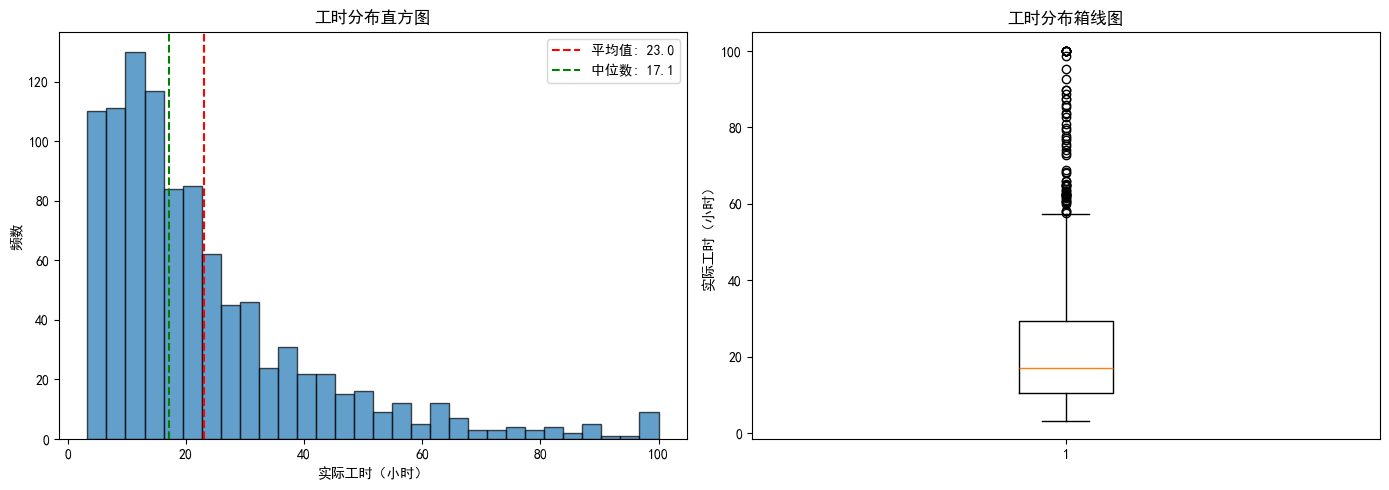


工时统计:
  最小值: 3.3 小时
  最大值: 100.0 小时
  平均值: 23.0 小时
  中位数: 17.1 小时
  标准差: 18.4 小时


In [16]:
# 目标变量分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 直方图
axes[0].hist(df['actual_hours'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('实际工时（小时）')
axes[0].set_ylabel('频数')
axes[0].set_title('工时分布直方图')
axes[0].axvline(df['actual_hours'].mean(), color='red', linestyle='--', label=f'平均值: {df["actual_hours"].mean():.1f}')
axes[0].axvline(df['actual_hours'].median(), color='green', linestyle='--', label=f'中位数: {df["actual_hours"].median():.1f}')
axes[0].legend()

# 箱线图
axes[1].boxplot(df['actual_hours'])
axes[1].set_ylabel('实际工时（小时）')
axes[1].set_title('工时分布箱线图')

plt.tight_layout()
plt.show()

print(f"\n工时统计:")
print(f"  最小值: {df['actual_hours'].min():.1f} 小时")
print(f"  最大值: {df['actual_hours'].max():.1f} 小时")
print(f"  平均值: {df['actual_hours'].mean():.1f} 小时")
print(f"  中位数: {df['actual_hours'].median():.1f} 小时")
print(f"  标准差: {df['actual_hours'].std():.1f} 小时")

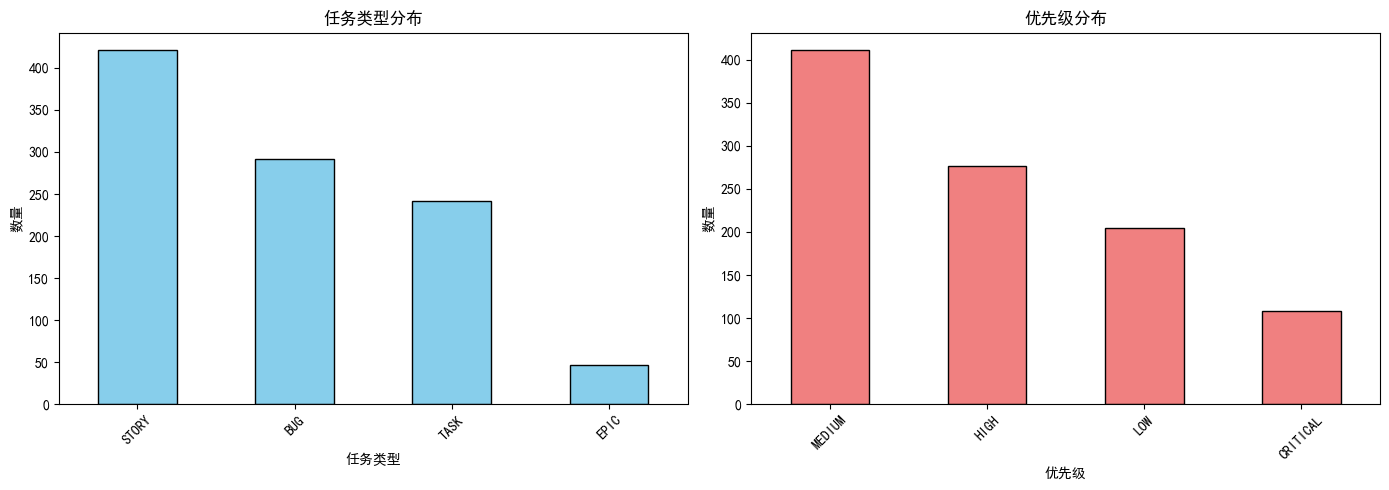

In [17]:
# 类别特征分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 任务类型分布
df['task_type'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_xlabel('任务类型')
axes[0].set_ylabel('数量')
axes[0].set_title('任务类型分布')
axes[0].tick_params(axis='x', rotation=45)

# 优先级分布
df['priority'].value_counts().plot(kind='bar', ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_xlabel('优先级')
axes[1].set_ylabel('数量')
axes[1].set_title('优先级分布')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

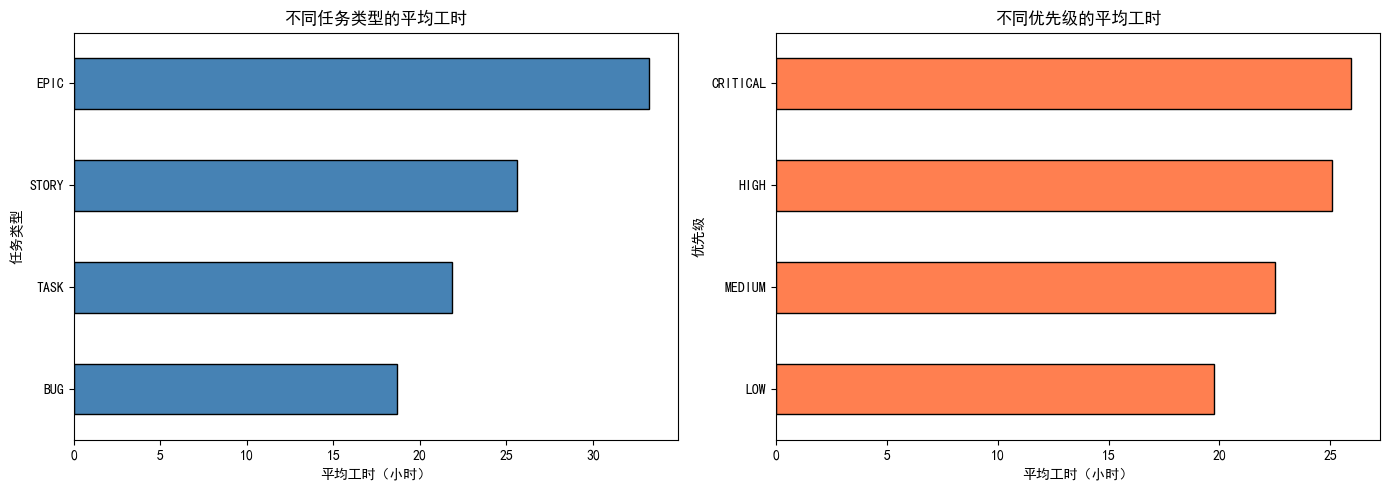

In [18]:
# 不同任务类型的平均工时
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 按任务类型
type_hours = df.groupby('task_type')['actual_hours'].mean().sort_values()
type_hours.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel('平均工时（小时）')
axes[0].set_ylabel('任务类型')
axes[0].set_title('不同任务类型的平均工时')

# 按优先级
priority_hours = df.groupby('priority')['actual_hours'].mean().sort_values()
priority_hours.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_xlabel('平均工时（小时）')
axes[1].set_ylabel('优先级')
axes[1].set_title('不同优先级的平均工时')

plt.tight_layout()
plt.show()

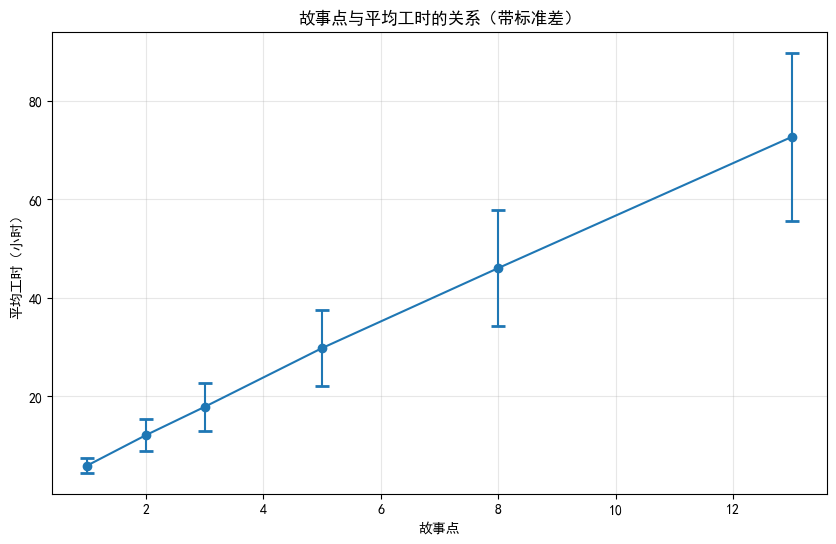


故事点与工时统计:
                   mean        std  count
story_points                             
1              5.982692   1.470140    156
2             12.149587   3.193695    242
3             17.884711   4.832014    242
5             29.803398   7.708737    206
8             46.025532  11.806304     94
13            72.636667  17.063987     60


In [19]:
# 故事点与工时的关系
plt.figure(figsize=(10, 6))
story_point_hours = df.groupby('story_points')['actual_hours'].agg(['mean', 'std', 'count'])
plt.errorbar(story_point_hours.index, story_point_hours['mean'], 
             yerr=story_point_hours['std'], fmt='o-', capsize=5, capthick=2)
plt.xlabel('故事点')
plt.ylabel('平均工时（小时）')
plt.title('故事点与平均工时的关系（带标准差）')
plt.grid(True, alpha=0.3)
plt.show()

print("\n故事点与工时统计:")
print(story_point_hours)

## 步骤 4: 特征工程

In [20]:
# 分离特征和目标变量
X = df.drop('actual_hours', axis=1)
y = df['actual_hours']

print(f"特征矩阵形状: {X.shape}")
print(f"目标变量形状: {y.shape}")
print(f"\n特征列表:")
print(X.columns.tolist())

特征矩阵形状: (1000, 12)
目标变量形状: (1000,)

特征列表:
['task_type', 'priority', 'story_points', 'title_length', 'description_length', 'labels_count', 'created_month', 'created_quarter', 'created_day_of_week', 'days_to_due', 'assignee_id', 'project_id']


In [21]:
# 类别特征编码
categorical_cols = ['task_type', 'priority']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[f'{col}_encoded'] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"\n{col} 编码映射:")
    for i, label in enumerate(le.classes_):
        print(f"  {label} → {i}")

# 删除原始类别列
X = X.drop(categorical_cols, axis=1)

print(f"\n编码后的特征列表:")
print(X.columns.tolist())


task_type 编码映射:
  BUG → 0
  EPIC → 1
  STORY → 2
  TASK → 3

priority 编码映射:
  CRITICAL → 0
  HIGH → 1
  LOW → 2
  MEDIUM → 3

编码后的特征列表:
['story_points', 'title_length', 'description_length', 'labels_count', 'created_month', 'created_quarter', 'created_day_of_week', 'days_to_due', 'assignee_id', 'project_id', 'task_type_encoded', 'priority_encoded']


## 步骤 5: 划分训练集和测试集

In [22]:
# 划分数据集（80% 训练，20% 测试）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"训练集大小: {X_train.shape[0]} 条")
print(f"测试集大小: {X_test.shape[0]} 条")
print(f"\n训练集工时统计:")
print(f"  平均值: {y_train.mean():.1f} 小时")
print(f"  标准差: {y_train.std():.1f} 小时")
print(f"\n测试集工时统计:")
print(f"  平均值: {y_test.mean():.1f} 小时")
print(f"  标准差: {y_test.std():.1f} 小时")

训练集大小: 800 条
测试集大小: 200 条

训练集工时统计:
  平均值: 23.3 小时
  标准差: 18.5 小时

测试集工时统计:
  平均值: 22.0 小时
  标准差: 17.9 小时


## 步骤 6: 训练 XGBoost 模型

In [23]:
# 定义模型参数
params = {
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 200,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

print("模型参数:")
for key, value in params.items():
    print(f"  {key}: {value}")

模型参数:
  objective: reg:squarederror
  max_depth: 6
  learning_rate: 0.1
  n_estimators: 200
  subsample: 0.8
  colsample_bytree: 0.8
  random_state: 42


In [24]:
# 训练模型
print("开始训练模型...\n")

model = xgb.XGBRegressor(**params)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=10  # 每 10 轮打印一次
)

print("\n✅ 模型训练完成！")

开始训练模型...

[0]	validation_0-rmse:16.21219
[10]	validation_0-rmse:7.98483
[20]	validation_0-rmse:5.28328
[30]	validation_0-rmse:4.70186
[40]	validation_0-rmse:4.38450
[50]	validation_0-rmse:4.23582
[60]	validation_0-rmse:4.18396
[70]	validation_0-rmse:4.14649
[80]	validation_0-rmse:4.13392
[90]	validation_0-rmse:4.10995
[100]	validation_0-rmse:4.09402
[110]	validation_0-rmse:4.09120
[120]	validation_0-rmse:4.09685
[130]	validation_0-rmse:4.10323
[140]	validation_0-rmse:4.10181
[150]	validation_0-rmse:4.09383
[160]	validation_0-rmse:4.10421
[170]	validation_0-rmse:4.11031
[180]	validation_0-rmse:4.11047
[190]	validation_0-rmse:4.11392
[199]	validation_0-rmse:4.11230

✅ 模型训练完成！


## 步骤 7: 模型评估

In [25]:
# 预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 计算评估指标
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("="*50)
print("模型评估结果")
print("="*50)
print(f"\n训练集:")
print(f"  MAE (平均绝对误差): {train_mae:.2f} 小时")
print(f"  RMSE (均方根误差): {train_rmse:.2f} 小时")
print(f"  R² (决定系数): {train_r2:.3f}")
print(f"\n测试集:")
print(f"  MAE (平均绝对误差): {test_mae:.2f} 小时")
print(f"  RMSE (均方根误差): {test_rmse:.2f} 小时")
print(f"  R² (决定系数): {test_r2:.3f}")
print("\n" + "="*50)

# 判断模型质量
if test_mae < 5:
    print("✅ 模型质量：优秀（MAE < 5 小时）")
elif test_mae < 10:
    print("✅ 模型质量：良好（MAE < 10 小时）")
else:
    print("⚠️ 模型质量：需要改进（MAE >= 10 小时）")

模型评估结果

训练集:
  MAE (平均绝对误差): 0.16 小时
  RMSE (均方根误差): 0.22 小时
  R² (决定系数): 1.000

测试集:
  MAE (平均绝对误差): 2.84 小时
  RMSE (均方根误差): 4.11 小时
  R² (决定系数): 0.947

✅ 模型质量：优秀（MAE < 5 小时）


In [26]:
# 预测准确率（±20% 误差内）
test_accuracy = np.mean(np.abs(y_test_pred - y_test) / y_test <= 0.2) * 100
print(f"预测准确率（±20% 误差内）: {test_accuracy:.1f}%")

预测准确率（±20% 误差内）: 77.0%


## 步骤 8: 可视化预测结果

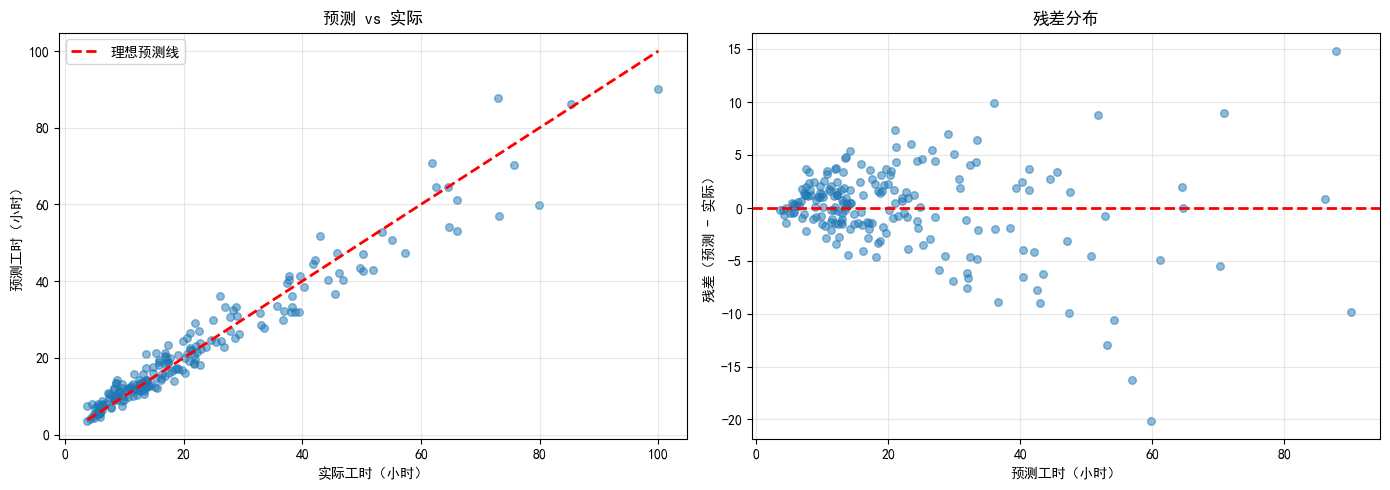

In [27]:
# 预测 vs 实际对比图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 散点图
axes[0].scatter(y_test, y_test_pred, alpha=0.5, s=30)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='理想预测线')
axes[0].set_xlabel('实际工时（小时）')
axes[0].set_ylabel('预测工时（小时）')
axes[0].set_title('预测 vs 实际')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 残差图
residuals = y_test_pred - y_test
axes[1].scatter(y_test_pred, residuals, alpha=0.5, s=30)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('预测工时（小时）')
axes[1].set_ylabel('残差（预测 - 实际）')
axes[1].set_title('残差分布')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

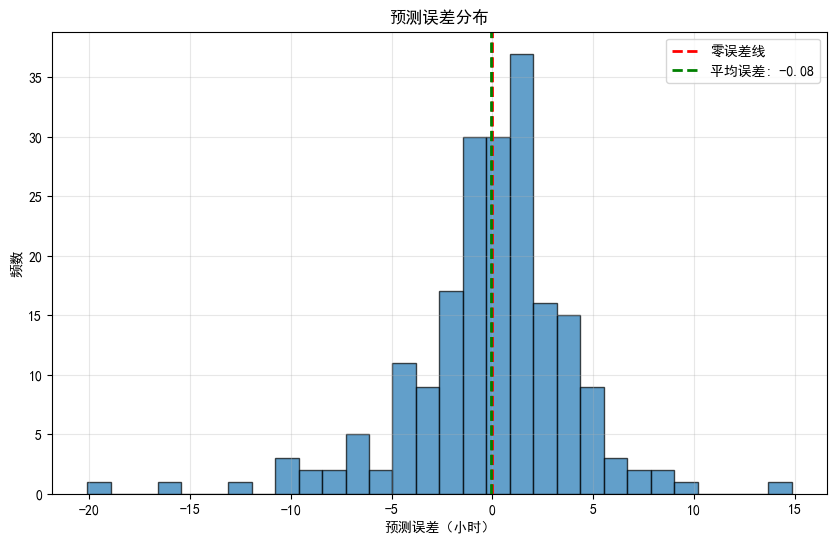

In [28]:
# 误差分布直方图
plt.figure(figsize=(10, 6))
errors = y_test_pred - y_test
plt.hist(errors, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='r', linestyle='--', lw=2, label='零误差线')
plt.axvline(x=errors.mean(), color='g', linestyle='--', lw=2, label=f'平均误差: {errors.mean():.2f}')
plt.xlabel('预测误差（小时）')
plt.ylabel('频数')
plt.title('预测误差分布')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 步骤 9: 特征重要性分析

特征重要性排名:
                feature  importance
0          story_points    0.791324
10    task_type_encoded    0.091430
11     priority_encoded    0.038908
8           assignee_id    0.012848
2    description_length    0.011821
6   created_day_of_week    0.011641
9            project_id    0.008386
3          labels_count    0.007784
5       created_quarter    0.007689
7           days_to_due    0.006933
1          title_length    0.006313
4         created_month    0.004922


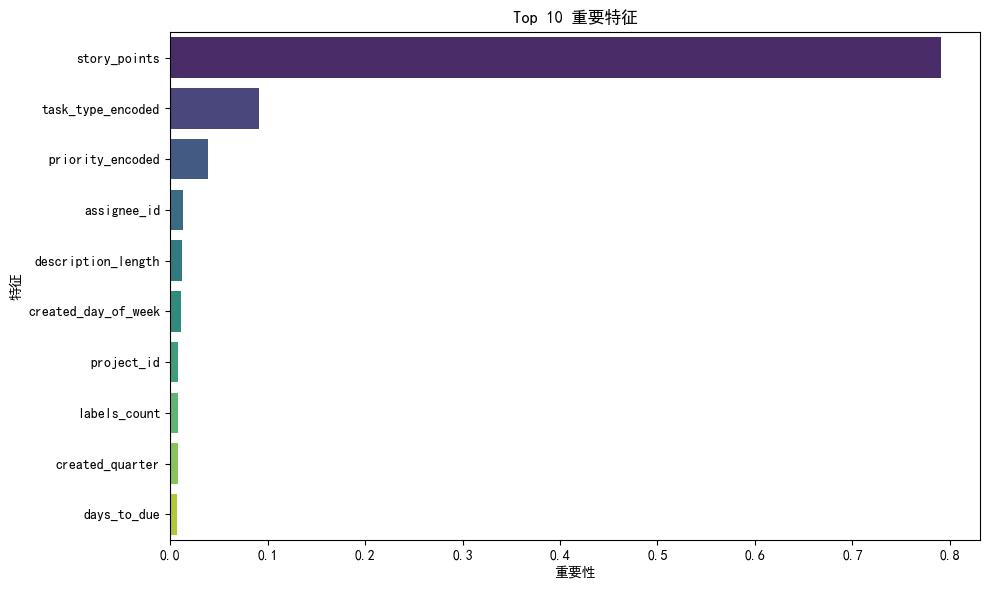

In [29]:
# 获取特征重要性
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("特征重要性排名:")
print(feature_importance)

# 可视化特征重要性
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature', palette='viridis')
plt.xlabel('重要性')
plt.ylabel('特征')
plt.title('Top 10 重要特征')
plt.tight_layout()
plt.show()

## 步骤 10: 保存模型

In [30]:
# 保存模型
joblib.dump(model, 'xgboost_model.pkl')
print("✅ 模型已保存到: xgboost_model.pkl")

# 保存编码器
joblib.dump(label_encoders, 'label_encoders.pkl')
print("✅ 编码器已保存到: label_encoders.pkl")

# 保存训练历史
import json
history = {
    'train_mae': float(train_mae),
    'test_mae': float(test_mae),
    'train_rmse': float(train_rmse),
    'test_rmse': float(test_rmse),
    'train_r2': float(train_r2),
    'test_r2': float(test_r2),
    'test_accuracy': float(test_accuracy),
    'feature_importance': feature_importance.to_dict('records')
}

with open('training_history.json', 'w', encoding='utf-8') as f:
    json.dump(history, f, indent=2, ensure_ascii=False)
print("✅ 训练历史已保存到: training_history.json")

✅ 模型已保存到: xgboost_model.pkl
✅ 编码器已保存到: label_encoders.pkl
✅ 训练历史已保存到: training_history.json


## 步骤 11: 测试预测

In [31]:
# 创建一个测试任务
test_task = pd.DataFrame([{
    'story_points': 5,
    'title_length': 45,
    'description_length': 200,
    'labels_count': 2,
    'created_month': 3,
    'created_quarter': 1,
    'created_day_of_week': 2,
    'days_to_due': 14,
    'assignee_id': 3,
    'project_id': 1,
    'task_type_encoded': 0,  # STORY
    'priority_encoded': 1     # HIGH
}])

# 预测
predicted_hours = model.predict(test_task)[0]

print("测试任务:")
print(f"  任务类型: STORY")
print(f"  优先级: HIGH")
print(f"  故事点: 5")
print(f"  标题长度: 45")
print(f"  描述长度: 200")
print(f"\n预测结果:")
print(f"  预测工时: {predicted_hours:.1f} 小时")

测试任务:
  任务类型: STORY
  优先级: HIGH
  故事点: 5
  标题长度: 45
  描述长度: 200

预测结果:
  预测工时: 25.1 小时


## 🎉 训练完成！

### 模型文件
- `xgboost_model.pkl` - 训练好的模型
- `label_encoders.pkl` - 特征编码器
- `training_history.json` - 训练历史和指标

### 下一步
1. 尝试调整模型参数（步骤 6）
2. 添加更多特征
3. 使用 GridSearchCV 进行超参数优化
4. 将模型部署为 API 服务